# Import

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tikzplotlib

# Results directory

In [2]:
RESULTS_DIR = Path("results/time_per_it_2")

# File

In [3]:
DATA = RESULTS_DIR / "compromise_results.csv"
COLLECTIVE = RESULTS_DIR / "collective_results.csv"
PATH = RESULTS_DIR / "path_results.csv"

# Read files

In [4]:
df = pd.read_csv(DATA)
df_collective = pd.read_csv(COLLECTIVE)
df_path = pd.read_csv(PATH)

In [5]:
df_collective

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie,Mie_config,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Time,Objective
0,3,100,1,1,1,2,0,1,10,True,...,False,NaN,1,1,1,True,1,0,0.249185,0.0
1,3,100,0,1,0,2,0,0,10,True,...,False,NaN,0,0,1,True,0,0,0.174861,0.0
2,3,100,4,1,4,2,0,4,10,True,...,False,NaN,4,4,1,True,4,0,0.326432,0.0
3,3,100,7,1,7,2,0,7,10,True,...,False,NaN,7,7,1,True,7,0,0.388711,0.0
4,3,100,5,1,5,2,0,5,10,True,...,False,NaN,5,5,1,True,5,0,0.490202,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,4,100,5,3,5,2,0,5,50,True,...,False,NaN,5,5,1,True,5,0,300.321093,4.0
337,4,100,6,3,6,2,0,6,50,True,...,False,NaN,6,6,1,True,6,0,300.297241,8.0
338,4,100,7,3,7,2,0,7,50,True,...,False,NaN,7,7,1,True,7,0,300.268941,8.0
339,4,100,8,3,8,2,0,8,50,True,...,False,NaN,8,8,1,True,8,0,300.288040,15.0


In [25]:
df_collective

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie,Mie_config,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Time,Objective
0,3,100,1,1,1,2,0,1,10,True,...,False,NaN,1,1,1,True,1,0,0.249185,0.0
1,3,100,0,1,0,2,0,0,10,True,...,False,NaN,0,0,1,True,0,0,0.174861,0.0
2,3,100,4,1,4,2,0,4,10,True,...,False,NaN,4,4,1,True,4,0,0.326432,0.0
3,3,100,7,1,7,2,0,7,10,True,...,False,NaN,7,7,1,True,7,0,0.388711,0.0
4,3,100,5,1,5,2,0,5,10,True,...,False,NaN,5,5,1,True,5,0,0.490202,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,4,100,5,3,5,2,0,5,50,True,...,False,NaN,5,5,1,True,5,0,300.321093,4.0
337,4,100,6,3,6,2,0,6,50,True,...,False,NaN,6,6,1,True,6,0,300.297241,8.0
338,4,100,7,3,7,2,0,7,50,True,...,False,NaN,7,7,1,True,7,0,300.268941,8.0
339,4,100,8,3,8,2,0,8,50,True,...,False,NaN,8,8,1,True,8,0,300.288040,15.0


In [26]:
df_path

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Dm_id,Time,Length,Model_Length
0,3,100,1,1,1,2,0,1,10,True,...,1,1,1,True,1,0,1,0.000003,0,1
1,3,100,1,1,1,2,0,1,10,True,...,1,1,1,True,1,0,0,0.036928,1,1
2,3,100,7,1,7,2,0,7,20,True,...,7,7,1,True,7,0,1,0.043680,1,1
3,3,100,7,1,7,2,0,7,20,True,...,7,7,1,True,7,0,0,0.000005,1,1
4,3,100,5,1,5,2,0,5,40,True,...,5,5,1,True,5,0,1,0.812244,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,4,100,4,3,4,2,0,4,20,True,...,4,4,1,True,4,0,1,0.000012,0,1
156,4,100,4,3,4,2,0,4,20,True,...,4,4,1,True,4,0,0,0.000005,0,1
157,4,100,2,3,2,2,0,2,30,True,...,2,2,1,True,2,0,0,0.000006,0,1
158,3,100,2,1,2,2,0,2,10,True,...,2,2,1,True,2,0,1,0.000008,0,1


# New attributes

In [28]:
df["Gen"] = np.array(["Homogene", "Heterogene"])[df["Group"] % 2]
df["Accept"] = np.array(["Conservative", "Tolerant"])[df["Group"] % 2]

df["Changes_Prop"] = df["Changes"] / (df["N_bc"] * df["Group_size"])

df_collective["Objective_Prop"] = df_collective["Objective"] / df_collective["N_bc"]

# Filter

In [ ]:
# dff = df[df["Fitness_train"] == 1]
# dff = df[df["N_tr"].isin([10, 20, 30, 80, 90, 100])]
# dff = df[df["N_tr"] % 20 == 0]
dff = df
dff = dff[~df["Mie"]]
dff = dff.drop(columns=["Mie", "Mie_id"])
# dff = dff[dff["Group_size"] == 2]
dff = dff[dff["Ko"] <= 3]
dff = dff[dff["Gen"] == "Homogene"]
dff = dff[dff["Path"]]
# dff = dff[dff["Compromise"]]

In [8]:
dff

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Nb_Mcp,Path,P_id,Compromise,Time,It,Changes,Gen,Accept,Changes_Prop
0,3,100,0,1,0,2,0,0,10,True,...,1,True,0,True,0.253809,1,0,Homogene,Conservative,0.00
1,3,100,7,1,7,2,0,7,10,True,...,1,True,7,True,0.447309,1,0,Homogene,Conservative,0.00
2,3,100,4,1,4,2,0,4,10,True,...,1,True,4,True,0.383027,1,0,Homogene,Conservative,0.00
3,3,100,1,1,1,2,0,1,10,True,...,1,True,1,True,0.742442,1,1,Homogene,Conservative,0.05
4,3,100,5,1,5,2,0,5,10,True,...,1,True,5,True,0.543682,1,1,Homogene,Conservative,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293,4,100,5,3,5,2,0,5,50,True,...,1,True,5,False,301.114840,1,0,Homogene,Conservative,0.00
294,4,100,6,3,6,2,0,6,50,True,...,1,True,6,False,301.020156,1,0,Homogene,Conservative,0.00
295,4,100,7,3,7,2,0,7,50,True,...,1,True,7,False,300.685722,1,0,Homogene,Conservative,0.00
296,4,100,8,3,8,2,0,8,50,True,...,1,True,8,False,301.033881,1,0,Homogene,Conservative,0.00


# Merge data

In [ ]:
# df = pd.merge(
#     df_mip,
#     df_path,
#     how="left",
#     on=[
#         "M",
#         "N_tr",
#         "Atr_id",
#         "Ko",
#         "Mo_id",
#         "Group_size",
#         "Group",
#         "Mi_id",
#         "N_bc",
#         "Same_alt",
#         "D_id",
#         "Config",
#         "Mc_id",
#         "Path",
#         "P_id",
#         "It"
#     ],
#     suffixes=["_mip", "_path"],
# )


df_compromise_path = dff[dff["Path"]]
df_compromise_path = df_compromise_path[df_compromise_path["Compromise"]]
df_compromise_path_index = df_compromise_path.drop(
    columns=["Path", "Compromise", "Time", "It", "Changes", "Changes_Prop"]
)
df_compromise_no_path = dff[~dff["Path"]]
df_compromise_no_path = df_compromise_no_path[df_compromise_no_path["Compromise"]]
df_compromise_no_path_index = df_compromise_no_path.drop(
    columns=["Path", "Compromise", "Time", "It", "Changes", "Changes_Prop"]
)

df_compromise_index = pd.merge(
    df_compromise_path_index,
    df_compromise_no_path_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
)

df_compromise_path = pd.merge(
    df_compromise_path,
    df_compromise_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
    suffixes=["", ""],
)

df_compromise_no_path = pd.merge(
    df_compromise_no_path,
    df_compromise_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
    suffixes=["", ""],
)

# df_compromise = pd.merge(
#     df_compromise_path,
#     df_compromise_no_path,
#     how="inner",
#     on=[
#         "M",
#         "N_tr",
#         "Atr_id",
#         "Ko",
#         "Mo_id",
#         "Group_size",
#         "Group",
#         "Mi_id",
#         "N_bc",
#         "Same_alt",
#         "D_id",
#         "Config",
#         "Mie",
#         "P_id",
#         "Mie_id",
#         "Mc_id",
#         "P_id",
#         "Gen",
#         "Accept"
#     ],
#     suffixes=["_path", "_no_path"],
# )

df_compromise = pd.concat([df_compromise_path, df_compromise_no_path])

df_compromise

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Changes,Gen,Accept,Changes_Prop,Method_x,Mie_config_x,Nb_Mcp_x,Method_y,Mie_config_y,Nb_Mcp_y


# Plot

Text(0.5, 0.98, 'Proportion of instances reaching compromise')

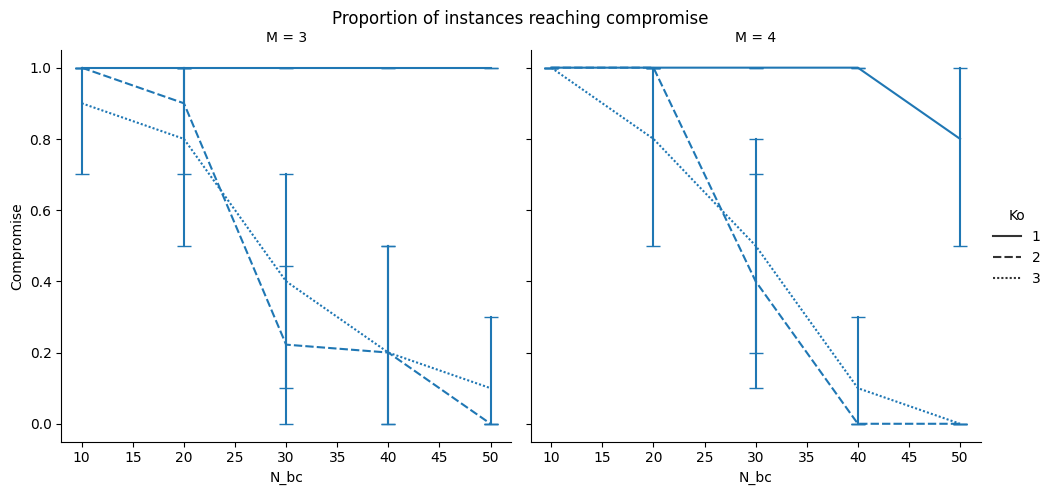

In [22]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="Compromise",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Proportion of instances reaching compromise")

Text(0.5, 0.98, 'Computing time for collective model (MILP)')

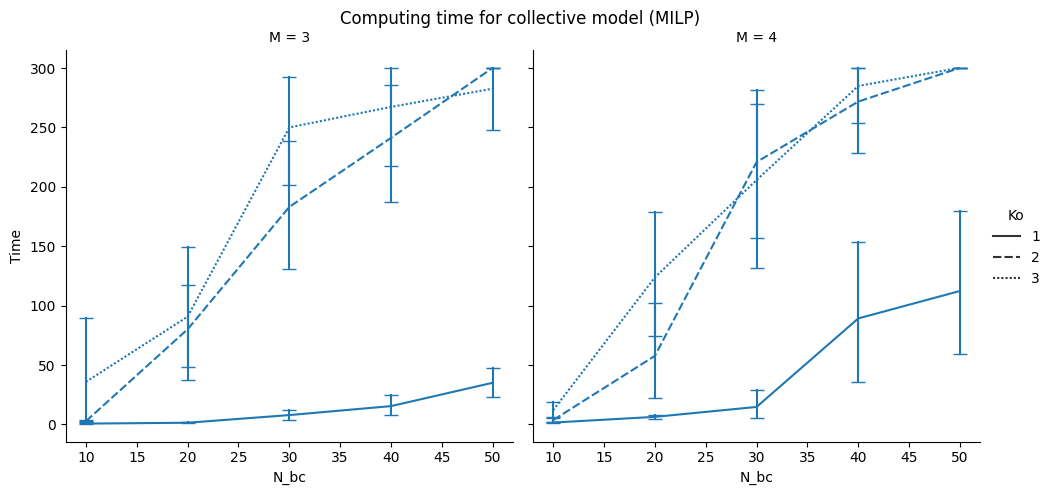

In [38]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Time",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for collective model (MILP)")

Text(0.5, 0.98, 'Computing time for preference path')

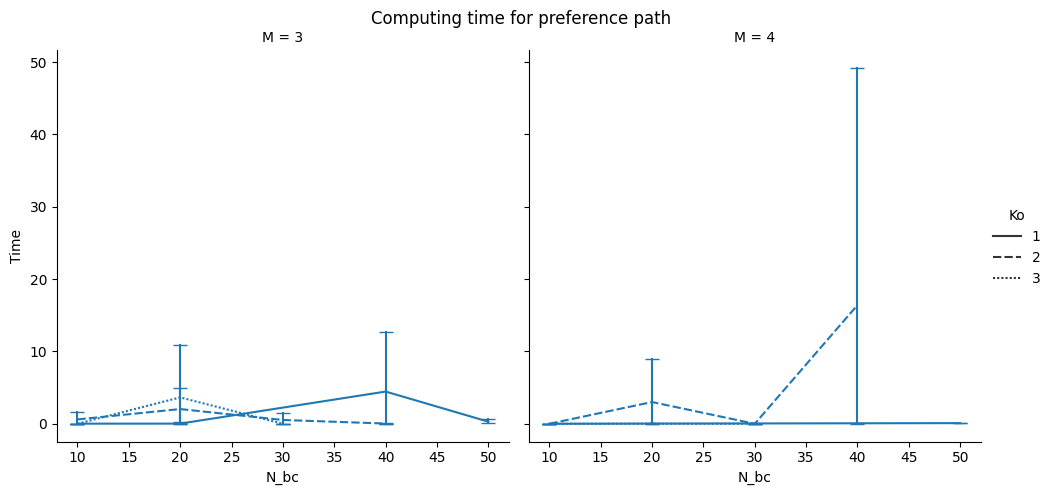

In [36]:
g = sns.relplot(
    df_path,
    x="N_bc",
    y="Time",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for preference path")

Text(0.5, 0.98, 'Number of iterations')

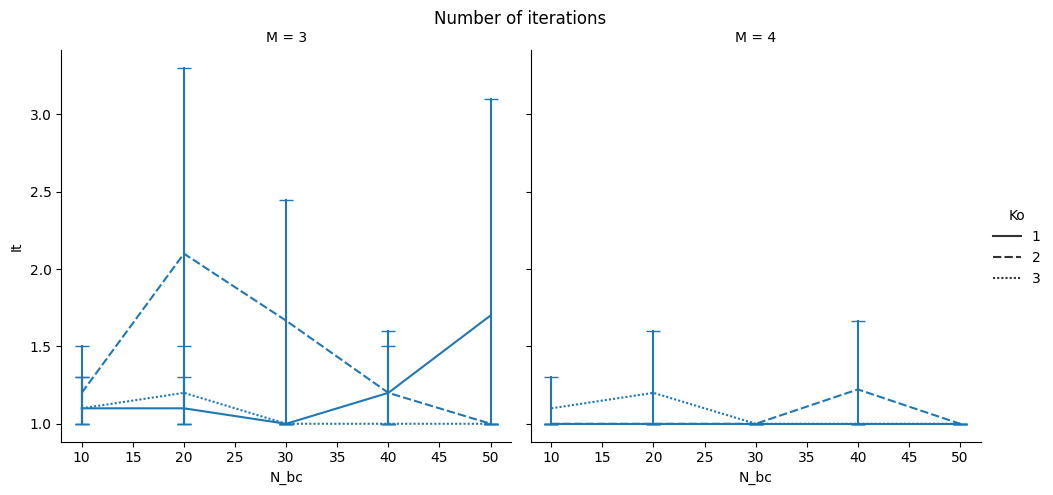

In [24]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="It",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Number of iterations")

Text(0.5, 0.98, 'Max number of comparisons to change for DMs')

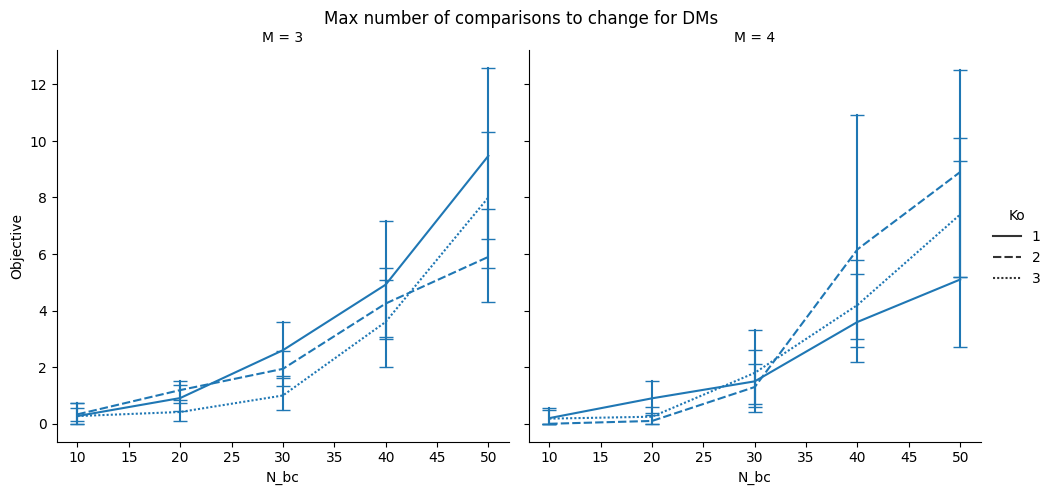

In [37]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Objective",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max number of comparisons to change for DMs")

Text(0.5, 0.98, 'Max proportion of comparisons to change for DMs')

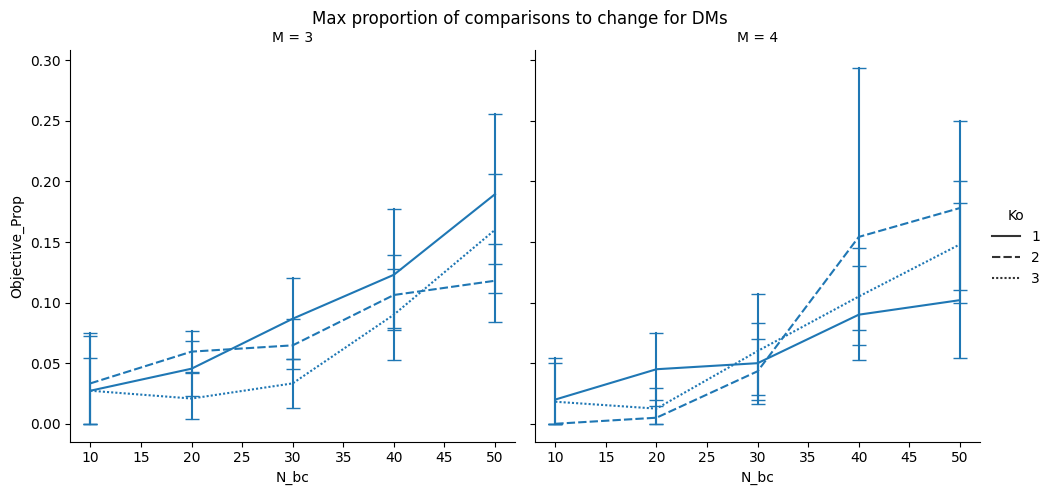

In [31]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Objective_Prop",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max proportion of comparisons to change for DMs")